# 0. Cargar datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 0.1. Ventas

In [2]:
# Cargar datos
path_ventas_2024 = "datos/Ventas por Cliente Padre/Ventas 2024.xlsx"
ventas_2024 = pd.read_excel(path_ventas_2024, header=1)
print("Ventas 2024:", ventas_2024.shape[0])
ventas_2024.head()

Ventas 2024: 671165


,Unnamed: 0,Año,Mes,Cod Canal Comercial,Fecha Factura,Cod Cliente Padre,Nombre Cliente Padre,Nombre Consolidado,Nombre Familia,Nombre Marca,Nombre Tipo Carne,Cod SKU,Nombre SKU,Kilo Real,Monto Real,Precio Venta
0,NaN,2024.0,4.0,CB,20240401.0,1005532.0,ROMANINI GAINZA LIMITADA,VOLUMEN COBERTURA,PARRILLEROS,WINTER,CERDO,8082.0,CHORIZOS 1 KG WIN,-1.000,-2503.0,2503.000000
1,NaN,2024.0,4.0,CB,20240401.0,1006790.0,GARFE JARUFE EDUARDO,COBERTURA,ARROLLADOS,SAN JORGE,CERDO,20.0,ARROLLADO LOMO CON AJI SJ,3.172,14762.0,4653.846154
2,NaN,2024.0,4.0,CB,20240401.0,1006790.0,GARFE JARUFE EDUARDO,COBERTURA,ARROLLADOS,SAN JORGE,CERDO,30.0,ARROLLADO HUASO CON AJI SJ,1.468,6832.0,4653.950954
3,NaN,2024.0,4.0,CB,20240401.0,1006790.0,GARFE JARUFE EDUARDO,COBERTURA,FIAMBRES,SAN JORGE,CERDO,210.0,FIAMBRE SANDWICH SJ,6.996,23514.0,3361.063465
4,NaN,2024.0,4.0,CB,20240401.0,1006790.0,GARFE JARUFE EDUARDO,COBERTURA,JAMON G1,LA PREFERIDA,CERDO,3256.0,JAMON PIERNA ARTESANAL LP,4.550,29411.0,6463.956044


In [3]:
path_ventas_2025 = "datos/Ventas por Cliente Padre/Ventas 2025.xlsx"
ventas_2025 = pd.read_excel(path_ventas_2025, header=1)
print("Ventas 2025:", ventas_2025.shape[0])
ventas_2025.head()

Ventas 2025: 482579


,Unnamed: 0,Año,Mes,Cod Canal Comercial,Fecha Factura,Cod Cliente Padre,Nombre Cliente Padre,Nombre Consolidado,Nombre Familia,Nombre Marca,Nombre Tipo Carne,Cod SKU,Nombre SKU,Kilo Real,Monto Real,Precio
0,NaN,2025,1,CB,20250102,1006790.0,GARFE JARUFE EDUARDO,COBERTURA,ARROLLADOS,SAN JORGE,CERDO,20,ARROLLADO LOMO CON AJI SJ,2.785,13683,4913.105925
1,NaN,2025,1,CB,20250102,1006790.0,GARFE JARUFE EDUARDO,COBERTURA,ARROLLADOS,SAN JORGE,CERDO,27,ARROLLADO LOMO SIN AJI SJ,3.045,14960,4912.972085
2,NaN,2025,1,CB,20250102,1006790.0,GARFE JARUFE EDUARDO,COBERTURA,ARROLLADOS,SAN JORGE,CERDO,30,ARROLLADO HUASO CON AJI SJ,4.265,20954,4913.012896
3,NaN,2025,1,CB,20250102,1006790.0,GARFE JARUFE EDUARDO,COBERTURA,CARNES,LA PREFERIDA,VACUNO,3191,CHURRASCO LP 90 G.,1.800,16807,9337.222222
4,NaN,2025,1,CB,20250102,1006790.0,GARFE JARUFE EDUARDO,COBERTURA,CARNES,SAN JORGE,VACUNO,970,MOLIDA 14x250 GR SJ,7.000,28959,4137.000000


In [4]:
ventas = pd.concat([ventas_2024, ventas_2025], ignore_index=True)
print("Ventas totales:", ventas.shape[0])
ventas.head()

Ventas totales: 1153744


,Unnamed: 0,Año,Mes,Cod Canal Comercial,Fecha Factura,Cod Cliente Padre,Nombre Cliente Padre,Nombre Consolidado,Nombre Familia,Nombre Marca,Nombre Tipo Carne,Cod SKU,Nombre SKU,Kilo Real,Monto Real,Precio Venta,Precio
0,NaN,2024.0,4.0,CB,20240401.0,1005532.0,ROMANINI GAINZA LIMITADA,VOLUMEN COBERTURA,PARRILLEROS,WINTER,CERDO,8082.0,CHORIZOS 1 KG WIN,-1.000,-2503.0,2503.000000,NaN
1,NaN,2024.0,4.0,CB,20240401.0,1006790.0,GARFE JARUFE EDUARDO,COBERTURA,ARROLLADOS,SAN JORGE,CERDO,20.0,ARROLLADO LOMO CON AJI SJ,3.172,14762.0,4653.846154,NaN
2,NaN,2024.0,4.0,CB,20240401.0,1006790.0,GARFE JARUFE EDUARDO,COBERTURA,ARROLLADOS,SAN JORGE,CERDO,30.0,ARROLLADO HUASO CON AJI SJ,1.468,6832.0,4653.950954,NaN
3,NaN,2024.0,4.0,CB,20240401.0,1006790.0,GARFE JARUFE EDUARDO,COBERTURA,FIAMBRES,SAN JORGE,CERDO,210.0,FIAMBRE SANDWICH SJ,6.996,23514.0,3361.063465,NaN
4,NaN,2024.0,4.0,CB,20240401.0,1006790.0,GARFE JARUFE EDUARDO,COBERTURA,JAMON G1,LA PREFERIDA,CERDO,3256.0,JAMON PIERNA ARTESANAL LP,4.550,29411.0,6463.956044,NaN


In [5]:
# Filtrar columnas relevantes
cols_relevantes_ventas = [
    # Id Cliente Padre
    "Cod Cliente Padre", 
    # Info Cliente Padre
    "Nombre Cliente Padre", "Cod Canal Comercial",
    # Fecha Venta
    "Año", "Mes",
    # Id Producto
    "Cod SKU",
    # Info Producto
    "Nombre SKU",
    # Monto Venta
    "Monto Real",
    # Cantidad Venta
    "Kilo Real",
    ]
ventas = ventas[cols_relevantes_ventas]
ventas.head()

,Cod Cliente Padre,Nombre Cliente Padre,Cod Canal Comercial,Año,Mes,Cod SKU,Nombre SKU,Monto Real,Kilo Real
0,1005532.0,ROMANINI GAINZA LIMITADA,CB,2024.0,4.0,8082.0,CHORIZOS 1 KG WIN,-2503.0,-1.000
1,1006790.0,GARFE JARUFE EDUARDO,CB,2024.0,4.0,20.0,ARROLLADO LOMO CON AJI SJ,14762.0,3.172
2,1006790.0,GARFE JARUFE EDUARDO,CB,2024.0,4.0,30.0,ARROLLADO HUASO CON AJI SJ,6832.0,1.468
3,1006790.0,GARFE JARUFE EDUARDO,CB,2024.0,4.0,210.0,FIAMBRE SANDWICH SJ,23514.0,6.996
4,1006790.0,GARFE JARUFE EDUARDO,CB,2024.0,4.0,3256.0,JAMON PIERNA ARTESANAL LP,29411.0,4.550


In [6]:
# Contar nans por columna
nans_por_columna = ventas.isna().sum()
print("Nans por columna:")
print(nans_por_columna)

Nans por columna:
Cod Cliente Padre       667813
Nombre Cliente Padre    667813
Cod Canal Comercial     313072
Año                     313072
Mes                     313072
Cod SKU                 313072
Nombre SKU              313072
Monto Real              313072
Kilo Real               313072
dtype: int64


In [7]:
# Indicar cuantas filas y columnas tiene el dataframe antes de filtrar
print(f"El dataframe tiene {ventas.shape[0]} filas y {ventas.shape[1]} columnas antes de filtrar.")

# Filtrar datos con nans en alguna columna relevante
ventas = ventas.dropna(subset=cols_relevantes_ventas)

# Indicar cuantas filas y columnas tiene el dataframe después de filtrar
print(f"El dataframe tiene {ventas.shape[0]} filas y {ventas.shape[1]} columnas después de filtrar.")

El dataframe tiene 1153744 filas y 9 columnas antes de filtrar.
El dataframe tiene 485931 filas y 9 columnas después de filtrar.


## 0.2. Maestro SKUs

In [8]:
# Cargar datos
path_maestro = "datos/Maestro Productos.xlsx"
maestro = pd.read_excel(path_maestro, header=2)
maestro.head()

,Material,Texto breve de material,Material - COD SKU,Grupo art.,Creado el,Estado,Válido de,GTPos,Denominación,Bruto,...,Denominación.1,Tip Carne,Denom..1,Gr. Empaq.,Denom..2,Gr. Carga,Denominación.2,Conservación,Jerarquía Clte.(Familia DP),Descripción
0,20,ARROLLADO LOMO CON AJI SJ,20,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,3.170,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel
1,21,ARROLLADO LOMO CORTADO SJ,21,SJ,20.10.2005,BLOQUEADO,19.10.2020,NORM,Posición normal,2.030,...,INSTITUCIONAL,5,CERDO,5,ENVASADO,35,LAMINADOS,60,A00010000200003,Arrollados-Laminados-Autoservicio
2,25,ARROLLADO LOMO S/AJI LAM.AUTO.12X250 SJ,25,SJ,27.01.2011,BLOQUEADO,08.04.2016,NORM,Posición normal,0.253,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
3,26,ARROLLADO LOMO S/A AUTOSERVICIO 250 GRS.,26,SJ,23.05.2013,BLOQUEADO,18.03.2020,NORM,Posición normal,0.256,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
4,27,ARROLLADO LOMO SIN AJI SJ,27,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,3.389,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel


In [9]:
# Filtrar columnas relevantes
cols_relevantes_maestro = [
    # Id Producto
    "Material",
    # Info Producto
    "Texto breve de material",
    # Producto con peso cte?
    "Peso Var/Std",
    # Kg por Unidad
    "Neto"
]
maestro = maestro[cols_relevantes_maestro]
maestro["peso_variable"] = maestro["Peso Var/Std"] != "Peso Standard"
maestro.drop(columns="Peso Var/Std", inplace=True)
maestro.head()

,Material,Texto breve de material,Neto,peso_variable
0,20,ARROLLADO LOMO CON AJI SJ,3.172,True
1,21,ARROLLADO LOMO CORTADO SJ,2.000,False
2,25,ARROLLADO LOMO S/AJI LAM.AUTO.12X250 SJ,0.250,False
3,26,ARROLLADO LOMO S/A AUTOSERVICIO 250 GRS.,0.250,False
4,27,ARROLLADO LOMO SIN AJI SJ,3.268,True


# 1. Cruzar bases

In [10]:
# Normalizar nombres de columnas
ventas.columns = [
    "cod_cliente_padre",
    "nombre_cliente_padre",
    "cod_canal_comercial",
    "año",
    "mes",
    "cod_sku",
    "nombre_sku",
    "monto_real",
    "kilo_real"
]

maestro.columns = [
    "cod_sku",
    "texto_breve_material",
    "kg_por_unidad",
    "peso_variable"
]

In [11]:
# Agregar columna de kg_por_unidad a ventas
ventas = ventas.merge(maestro[["cod_sku", "kg_por_unidad", "peso_variable"]], on="cod_sku", how="left")

# Calcular cantidad en unidades
ventas["cantidad_unidades"] = ventas["kilo_real"] / ventas["kg_por_unidad"]
ventas.head()

,cod_cliente_padre,nombre_cliente_padre,cod_canal_comercial,año,mes,cod_sku,nombre_sku,monto_real,kilo_real,kg_por_unidad,peso_variable,cantidad_unidades
0,1005532.0,ROMANINI GAINZA LIMITADA,CB,2024.0,4.0,8082.0,CHORIZOS 1 KG WIN,-2503.0,-1.000,1.000,False,-1.000000
1,1006790.0,GARFE JARUFE EDUARDO,CB,2024.0,4.0,20.0,ARROLLADO LOMO CON AJI SJ,14762.0,3.172,3.172,True,1.000000
2,1006790.0,GARFE JARUFE EDUARDO,CB,2024.0,4.0,30.0,ARROLLADO HUASO CON AJI SJ,6832.0,1.468,1.468,True,1.000000
3,1006790.0,GARFE JARUFE EDUARDO,CB,2024.0,4.0,210.0,FIAMBRE SANDWICH SJ,23514.0,6.996,3.498,True,2.000000
4,1006790.0,GARFE JARUFE EDUARDO,CB,2024.0,4.0,3256.0,JAMON PIERNA ARTESANAL LP,29411.0,4.550,4.062,True,1.120138


In [12]:
# Revisar que columnas con cantidad_unidades no entera sean las mismas que las que tienen peso_variable = True
ventas["cantidad_unidades_entera"] = ventas["cantidad_unidades"].isna() | np.isclose(ventas["cantidad_unidades"], np.round(ventas["cantidad_unidades"]), atol=1e-6, rtol=0)

ventas["peso_variable"] = ventas["peso_variable"].fillna(False)
ventas["cantidad_unidades_entera"] = ventas["cantidad_unidades_entera"].fillna(True)
ventas["inconsistencia"] = (ventas["peso_variable"] == False) & (ventas["cantidad_unidades_entera"] == False)

ventas["inconsistencia"].value_counts()

inconsistencia
False    483321
True       2610
Name: count, dtype: int64

In [13]:
# Ver columnas con inconsistencia
ventas[ventas["inconsistencia"]].head()

,cod_cliente_padre,nombre_cliente_padre,cod_canal_comercial,año,mes,cod_sku,nombre_sku,monto_real,kilo_real,kg_por_unidad,peso_variable,cantidad_unidades,cantidad_unidades_entera,inconsistencia
634,1006790.0,GARFE JARUFE EDUARDO,CB,2024.0,4.0,399.0,MORTADELA LISA 3 KG SJ,-1034.0,-0.400,3.0,False,-0.133333,False,True
1383,1006790.0,GARFE JARUFE EDUARDO,CB,2024.0,4.0,8508.0,"SALCHICHON CERVEZA 1,6 KGS.WIN",-724.0,-0.200,1.6,False,-0.125000,False,True
1384,1006790.0,GARFE JARUFE EDUARDO,CB,2024.0,4.0,3456.0,"SALAME LAMINADO 1,6 KG LP",-1552.0,-0.200,1.6,False,-0.125000,False,True
1680,61140.0,SOC COM LOS ALPES,CB,2024.0,4.0,3032.0,SALCHICHON CERVEZA LP,-1731.0,-0.463,2.5,False,-0.185200,False,True
2164,1231301.0,CAMPOS BENITO Y COMPANIA LIMITADA,CB,2024.0,4.0,3456.0,"SALAME LAMINADO 1,6 KG LP",-8429.0,-1.120,1.6,False,-0.700000,False,True


In [14]:
# Decidir que hacer con estas filas
# -> Redondear unidades a entero, dejar registro en un columna unidades_redondeadas (Bool)
ventas["cantidad_unidades"] = np.where(ventas["inconsistencia"], np.round(ventas["cantidad_unidades"]), ventas["cantidad_unidades"])
ventas.head()

,cod_cliente_padre,nombre_cliente_padre,cod_canal_comercial,año,mes,cod_sku,nombre_sku,monto_real,kilo_real,kg_por_unidad,peso_variable,cantidad_unidades,cantidad_unidades_entera,inconsistencia
0,1005532.0,ROMANINI GAINZA LIMITADA,CB,2024.0,4.0,8082.0,CHORIZOS 1 KG WIN,-2503.0,-1.000,1.000,False,-1.000000,True,False
1,1006790.0,GARFE JARUFE EDUARDO,CB,2024.0,4.0,20.0,ARROLLADO LOMO CON AJI SJ,14762.0,3.172,3.172,True,1.000000,True,False
2,1006790.0,GARFE JARUFE EDUARDO,CB,2024.0,4.0,30.0,ARROLLADO HUASO CON AJI SJ,6832.0,1.468,1.468,True,1.000000,True,False
3,1006790.0,GARFE JARUFE EDUARDO,CB,2024.0,4.0,210.0,FIAMBRE SANDWICH SJ,23514.0,6.996,3.498,True,2.000000,True,False
4,1006790.0,GARFE JARUFE EDUARDO,CB,2024.0,4.0,3256.0,JAMON PIERNA ARTESANAL LP,29411.0,4.550,4.062,True,1.120138,False,False


# 2. Dispersión

In [15]:
# Filtrar ventas para tener sólo de unidades mayores a 0
ventas = ventas[ventas["cantidad_unidades"] > 0]

In [16]:
# Calcular precio por unidad en cada venta
ventas["precio_por_unidad"] = ventas["monto_real"] / ventas["cantidad_unidades"]
ventas.head()

,cod_cliente_padre,nombre_cliente_padre,cod_canal_comercial,año,mes,cod_sku,nombre_sku,monto_real,kilo_real,kg_por_unidad,peso_variable,cantidad_unidades,cantidad_unidades_entera,inconsistencia,precio_por_unidad
1,1006790.0,GARFE JARUFE EDUARDO,CB,2024.0,4.0,20.0,ARROLLADO LOMO CON AJI SJ,14762.0,3.172,3.172,True,1.000000,True,False,14762.000000
2,1006790.0,GARFE JARUFE EDUARDO,CB,2024.0,4.0,30.0,ARROLLADO HUASO CON AJI SJ,6832.0,1.468,1.468,True,1.000000,True,False,6832.000000
3,1006790.0,GARFE JARUFE EDUARDO,CB,2024.0,4.0,210.0,FIAMBRE SANDWICH SJ,23514.0,6.996,3.498,True,2.000000,True,False,11757.000000
4,1006790.0,GARFE JARUFE EDUARDO,CB,2024.0,4.0,3256.0,JAMON PIERNA ARTESANAL LP,29411.0,4.550,4.062,True,1.120138,False,False,26256.589451
5,1006790.0,GARFE JARUFE EDUARDO,CB,2024.0,4.0,1372.0,JAMON COLONIAL MINI PZA SJ,45376.0,7.630,3.815,True,2.000000,True,False,22688.000000


In [17]:
# Calcular precio promedio por unidad para cada SKU-mes-año
precio_promedio_por_unidad = ventas.groupby(["cod_sku", "mes", "año"])["precio_por_unidad"].mean().reset_index().rename(columns={"precio_por_unidad": "precio_promedio_por_unidad"})
precio_promedio_por_unidad.head()

,cod_sku,mes,año,precio_promedio_por_unidad
0,20.0,1.0,2025.0,15002.213347
1,20.0,2.0,2025.0,15013.900000
2,20.0,3.0,2025.0,15011.068123
3,20.0,4.0,2024.0,14224.866420
4,20.0,4.0,2025.0,15015.128964


In [18]:
# Calcular desviación porcentual del precio por unidad respecto al precio promedio para cada venta según SKU-mes-año
ventas = ventas.merge(precio_promedio_por_unidad, on=["cod_sku", "mes", "año"], how="left")
ventas["desviacion_porcentual_precio_por_unidad"] = (ventas["precio_por_unidad"] - ventas["precio_promedio_por_unidad"]) / ventas["precio_promedio_por_unidad"] * 100
ventas.head()

,cod_cliente_padre,nombre_cliente_padre,cod_canal_comercial,año,mes,cod_sku,nombre_sku,monto_real,kilo_real,kg_por_unidad,peso_variable,cantidad_unidades,cantidad_unidades_entera,inconsistencia,precio_por_unidad,precio_promedio_por_unidad,desviacion_porcentual_precio_por_unidad
0,1006790.0,GARFE JARUFE EDUARDO,CB,2024.0,4.0,20.0,ARROLLADO LOMO CON AJI SJ,14762.0,3.172,3.172,True,1.000000,True,False,14762.000000,14224.866420,3.776018
1,1006790.0,GARFE JARUFE EDUARDO,CB,2024.0,4.0,30.0,ARROLLADO HUASO CON AJI SJ,6832.0,1.468,1.468,True,1.000000,True,False,6832.000000,6592.798208,3.628229
2,1006790.0,GARFE JARUFE EDUARDO,CB,2024.0,4.0,210.0,FIAMBRE SANDWICH SJ,23514.0,6.996,3.498,True,2.000000,True,False,11757.000000,11296.695623,4.074682
3,1006790.0,GARFE JARUFE EDUARDO,CB,2024.0,4.0,3256.0,JAMON PIERNA ARTESANAL LP,29411.0,4.550,4.062,True,1.120138,False,False,26256.589451,25395.494849,3.390738
4,1006790.0,GARFE JARUFE EDUARDO,CB,2024.0,4.0,1372.0,JAMON COLONIAL MINI PZA SJ,45376.0,7.630,3.815,True,2.000000,True,False,22688.000000,21540.102999,5.329116


## 2.1 Dispersión e Importancia por SKU

### 2.1.1 Armar tablas

In [19]:
# Calcular ingreso total por SKU
ingreso_por_sku = ventas.groupby("cod_sku")["monto_real"].sum().reset_index().rename(columns={"monto_real": "ingreso_total"})
ingreso_por_sku.head()

,cod_sku,ingreso_total
0,20.0,275084660.0
1,27.0,34209081.0
2,30.0,208602211.0
3,102.0,43184474.0
4,151.0,67476217.0


In [20]:
# Calcular precio promedio por unidad para cada SKU
precio_promedio_por_unidad_sku = ventas.groupby("cod_sku")["precio_por_unidad"].mean().reset_index().rename(columns={"precio_por_unidad": "precio_promedio_por_unidad"})
precio_promedio_por_unidad_sku.head()

,cod_sku,precio_promedio_por_unidad
0,20.0,14622.508879
1,27.0,15004.635429
2,30.0,6665.265109
3,102.0,785.425334
4,151.0,844.335724


In [21]:
# Calcular tabla de dispersión de precio por unidad para cada SKU:
#   - desviación estándar
#   - iqr
desviacion_precio_por_unidad = ventas.groupby("cod_sku")["precio_por_unidad"].std().reset_index().rename(columns={"precio_por_unidad": "desviacion_precio_por_unidad"})
iqr_precio_por_unidad = ventas.groupby("cod_sku")["precio_por_unidad"].apply(lambda x: x.quantile(0.75) - x.quantile(0.25)).reset_index().rename(columns={"precio_por_unidad": "iqr_precio_por_unidad"})

# Combinar las tablas
dispersion_sku = desviacion_precio_por_unidad.merge(iqr_precio_por_unidad, on="cod_sku")
dispersion_sku.sort_values("desviacion_precio_por_unidad", ascending=False).head()
dispersion_sku.head()

,cod_sku,desviacion_precio_por_unidad,iqr_precio_por_unidad
0,20.0,2049.869585,799.287414
1,27.0,1283.307816,823.501318
2,30.0,5592.200863,369.883436
3,102.0,103.367368,25.180556
4,151.0,69.021529,62.750000


In [22]:
# Armar tabla con SKU, promedio por sku, medidas de dispersión, ingreso total y multiplicaciones de medidas de dispersión por ingreso total
tabla_sku = precio_promedio_por_unidad_sku.merge(dispersion_sku, on="cod_sku").merge(ingreso_por_sku, on="cod_sku")
tabla_sku["desviacion_por_unidad_por_ingreso"] = tabla_sku["desviacion_precio_por_unidad"] * tabla_sku["ingreso_total"]
tabla_sku["iqr_por_unidad_por_ingreso"] = tabla_sku["iqr_precio_por_unidad"] * tabla_sku["ingreso_total"]
tabla_sku.head()

,cod_sku,precio_promedio_por_unidad,desviacion_precio_por_unidad,iqr_precio_por_unidad,ingreso_total,desviacion_por_unidad_por_ingreso,iqr_por_unidad_por_ingreso
0,20.0,14622.508879,2049.869585,799.287414,275084660.0,5.638877e+11,2.198717e+11
1,27.0,15004.635429,1283.307816,823.501318,34209081.0,4.390078e+10,2.817122e+10
2,30.0,6665.265109,5592.200863,369.883436,208602211.0,1.166545e+12,7.715850e+10
3,102.0,785.425334,103.367368,25.180556,43184474.0,4.463865e+09,1.087409e+09
4,151.0,844.335724,69.021529,62.750000,67476217.0,4.657312e+09,4.234133e+09


In [23]:
# Tabla Resumen: SKU, nombre, precio promedio, relevancia (iqr_por_unidad_por_ingreso)
tabla_resumen = tabla_sku.merge(maestro[["cod_sku", "texto_breve_material"]], on="cod_sku", how="left")[["cod_sku", "texto_breve_material", "precio_promedio_por_unidad", "iqr_por_unidad_por_ingreso"]]
tabla_resumen.sort_values("iqr_por_unidad_por_ingreso", ascending=False).head()
tabla_resumen.head()

,cod_sku,texto_breve_material,precio_promedio_por_unidad,iqr_por_unidad_por_ingreso
0,20.0,ARROLLADO LOMO CON AJI SJ,14622.508879,2.198717e+11
1,27.0,ARROLLADO LOMO SIN AJI SJ,15004.635429,2.817122e+10
2,30.0,ARROLLADO HUASO CON AJI SJ,6665.265109,7.715850e+10
3,102.0,ARROLLADO LOMO CON AJI 12X150 GR SJ,785.425334,1.087409e+09
4,151.0,CHORIZO 12X250 GR SJ,844.335724,4.234133e+09


### 2.1.2. Gráficos

SKUs más importantes: [3456.  399. 1834. 8117. 1372. 8300.   30.  210. 8213. 3239. 8508. 1228.
 3001. 3109. 3032.   20. 1350. 8210. 8454. 1680.]


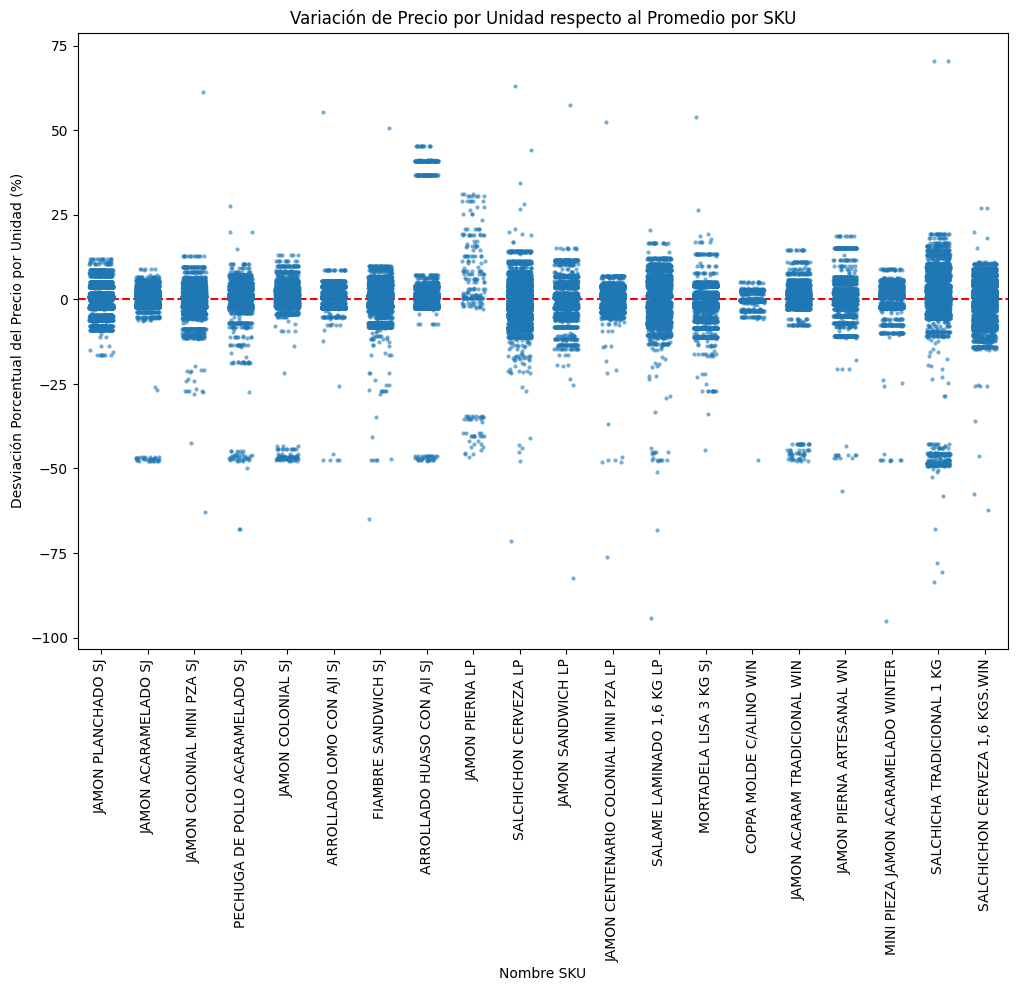

In [24]:
# Graficar  variación de precio unitario c/r a precio promedio (como porcentaje) agrupando por SKU
# Tomamos desviacion para cada sku
datos_grafico = ventas[["cod_sku", "nombre_sku", "cod_canal_comercial", "desviacion_porcentual_precio_por_unidad"]].copy()

# Filtrar ventas con desviación porcentual extrema (ej. > 100% o < -100%) para evitar distorsionar el gráfico
datos_grafico = datos_grafico[(datos_grafico["desviacion_porcentual_precio_por_unidad"] < 100) & (datos_grafico["desviacion_porcentual_precio_por_unidad"] > -100)]

# Filtrar y dejar sólo 20 SKUs más dispersos para visualizar
# skus_mas_disperos = dispersion_sku.sort_values("desviacion_precio_por_unidad", ascending=False).head(10)["cod_sku"]
# print("SKUs más dispersos:", skus_mas_disperos.values)
# datos_grafico = datos_grafico[datos_grafico["cod_sku"].isin(skus_mas_disperos)]
# datos_grafico["cod_sku_cat"] = datos_grafico["cod_sku"].astype(str)
# orden_skus = sorted(datos_grafico["cod_sku_cat"].unique())

# Filtrar y dejar sólo 20 SKUs con más importancia (desviacion_por_unidad_por_ingreso) para visualizar
skus_mas_importantes = tabla_sku.sort_values("desviacion_por_unidad_por_ingreso", ascending=False).head(20)["cod_sku"]
print("SKUs más importantes:", skus_mas_importantes.values)
datos_grafico = datos_grafico[datos_grafico["cod_sku"].isin(skus_mas_importantes)]
datos_grafico["cod_sku_cat"] = datos_grafico["cod_sku"].astype(str)
orden_skus = sorted(datos_grafico["cod_sku_cat"].unique())
nombre_por_cat = datos_grafico[["cod_sku_cat", "nombre_sku"]].drop_duplicates(subset=["cod_sku_cat"]).set_index("cod_sku_cat")["nombre_sku"]
etiquetas_x = [nombre_por_cat.get(cod, cod) for cod in orden_skus]

plt.figure(figsize=(12, 8))
ax = sns.stripplot(x="cod_sku_cat", y="desviacion_porcentual_precio_por_unidad", data=datos_grafico, order=orden_skus, jitter=0.25, alpha=0.6, size=3)
plt.axhline(0, color="red", linestyle="--")                     # Agregar linea punteada en y=0 para referencia
plt.title("Variación de Precio por Unidad respecto al Promedio por SKU")
plt.xlabel("Nombre SKU")
plt.ylabel("Desviación Porcentual del Precio por Unidad (%)")
plt.xticks(ticks=range(len(orden_skus)), labels=etiquetas_x, rotation=90)
plt.show()

In [28]:
canales = datos_grafico["cod_canal_comercial"].unique()
print("Canales comerciales presentes en el gráfico:", canales)

Canales comerciales presentes en el gráfico: <StringArray>
['CB', 'HR', 'MY']
Length: 3, dtype: str


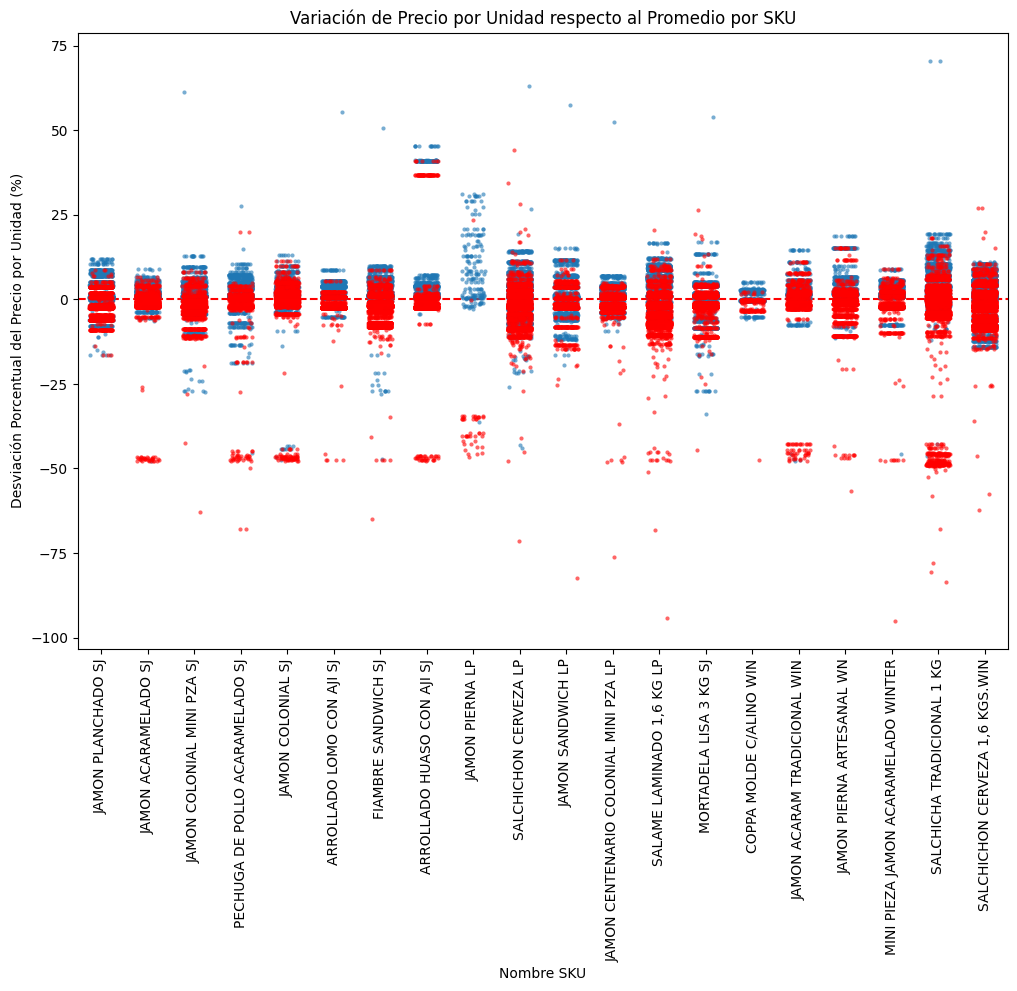

In [30]:
# Mismo gráfico pero con destacar algunos canales con color rojo
canales_destacados = ["MY"]
datos_destacados = datos_grafico[datos_grafico["cod_canal_comercial"].isin(canales_destacados) & datos_grafico["cod_sku"].isin(skus_mas_importantes)]
datos_no_destacados = datos_grafico[~datos_grafico["cod_canal_comercial"].isin(canales_destacados) & datos_grafico["cod_sku"].isin(skus_mas_importantes)]

plt.figure(figsize=(12, 8))
# Graficar todos los puntos en gris
ax = sns.stripplot(x="cod_sku_cat", y="desviacion_porcentual_precio_por_unidad", data=datos_no_destacados, order=orden_skus, jitter=0.25, alpha=0.6, size=3)
# Graficar los puntos destacados en rojo
sns.stripplot(x="cod_sku_cat", y="desviacion_porcentual_precio_por_unidad", data=datos_destacados, order=orden_skus, jitter=0.25, alpha=0.6, size=3, color="red")
plt.axhline(0, color="red", linestyle="--")                     # Agregar linea punteada en y=0 para referencia
plt.title("Variación de Precio por Unidad respecto al Promedio por SKU")
plt.xlabel("Nombre SKU")
plt.ylabel("Desviación Porcentual del Precio por Unidad (%)")
plt.xticks(ticks=range(len(orden_skus)), labels=etiquetas_x, rotation=90)
plt.show()

TODO
cambiar promedio a promedio del año,mes - OK
pintar segun R1 R2, ETC - esta bien?
PINTAR segun canal 
Pintar segun giro panaderia minimarket bla bla - hay diferencias estructurales entre canal y giro?
PINTAR segun sofistaccion - realmente los negocios sofisticados
Variaciones tienen un racional por detras

presentacion
1. como priorizamos - mostarar tabla de relevancia mencionar que aun no cuantificamos
2. mostrar dispersiones y dispersiones con cortes pintados r1-r5 y sofisticación
cuales son los siguientes pasos - discutir


In [ ]:
# Cargamos BBDD de ventas old para asociar cod_cliente_padre con

In [ ]:
# Diagrama de bigotes de precio por unidad para un SKU dado
# Sacando datos outliers para visualizar mejor
SKU_EJEMPLO = 8630  # Reemplazar con un SKU real

nombre_producto = maestro[maestro["cod_sku"] == SKU_EJEMPLO]["texto_breve_material"].values[0]

datos_sku = ventas[ventas["cod_sku"] == SKU_EJEMPLO]
plt.figure(figsize=(10, 6))
sns.boxplot(y=datos_sku["precio_por_unidad"], showfliers=False)
plt.title(f"Diagrama de Bigotes de Precio por Unidad para {nombre_producto}")
plt.ylabel("Precio por Unidad")
plt.show()

## 2.2 Dispersión por SKU-zona

# 3. Elasticidad

# 3.1. Elasticidad por SKU

# 3.2 Elasticidad por SKU-zona